# Exercise - Gradient descent

_______

Consider a voltage source $E$ connected in series with a diode $D$ and a resistance $R$.

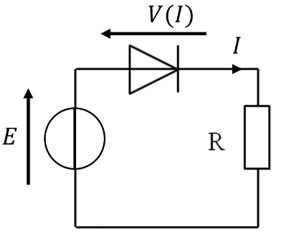

We assume that the current $I$ depends on the diode voltage $V$ such that

$$ I(V) = K \max(V,0) V,$$

with $K=1 A/V^2$. Our objective is to find the value $R^*$ that maximizes the dissipated power

$$ P(R) = \frac{(E-V(R))^2}{R},$$

with $E = 10 V$, and $V(R)$ the diode voltage that depends implicitly on $R$ through the resolution of the following state equation obtained from Kirchhoff voltage law:

$$ \mathcal S(V, R) = V + R I(V) - E = 0.$$

1. **Reference state solution**

Show that for a given $R>0$, the solution of the state equation is
$$ V(R) = \frac{\sqrt{1+4ERK}-1}{2RK},$$
and that $V(R=0)=E$.

In [ ]:
K = 1
E = 10
V = lambda R: E*(R==0) or ((1+4*E*R*K)**0.5 - 1)/(2*R*K)

import matplotlib.pyplot as plt
import numpy as np
Rlist = np.linspace(0,10,100)
plt.plot(Rlist, [V(r) for r in Rlist])
plt.xlabel("R [$\\Omega$]")
plt.ylabel("V [$V$]")
plt.show()

2. Show that the reference derivative is
- $V'(R<0) = \frac{E}{R\sqrt{1+4EKR}} - \frac{\sqrt{1+4EKR}-1}{2KR^2} $
- $V'(R=0) = -K E^2$

In [ ]:
def dV_dR(R):
    """ Explicit derivative of Vref(R) """
    if R==0: return -E**2*K
    else: return E/(R*(1+4*E*K*R)**0.5) - ((1+4*E*K*R)**0.5-1) / (2*K*R**2)

3. Check the expression of the derivative with finite difference and/or complex step methods. 

In [ ]:
R0 = 1
h = 1e-6

print(f"Analytical derivative:        {dV_dR(R0) :.5e}")
print(f"Finite difference derivative: {(V(R0+h)- V(R0))/h:.5e}")
print(f"Complex-step derivative:      {(V(R0+1j*h)).imag/h:.5e}")


4. Show that 
- $ R>0 \Rightarrow P'(R) = - \frac{(E-V(R))^2}{R^2} - \frac{2 (E - V(R))}{R} V'(R) $
- $ R=0 \Rightarrow P'(0) = E^4 K^2 $

In [ ]:
def dP_dR(R):
    if R==0: return(E**4*K**2)
    else: return - (E-V(R))**2 / R**2 - 2*(E-V(R))/R * dV_dR(R)

Since we want to solve a maximization problem, we consider the following objective function:
$$ \mathcal J(R) = - P(R) $$

In [ ]:
def P(R):
    if R > 0: return (E - V(R))**2/R
    else: return 0
J = lambda R: -P(R)
dJ_dR = lambda R: - dP_dR(R)

5. Check that $R^* = \frac{3}{4 E K}$ minimizes $\mathcal J$. This value is considered as the reference.

In [ ]:
Rstar = 3/(4*E*K)
print(f"1st derivative : dP/dR   = {-dP_dR(Rstar) :.3}") # cancel the first derivative
print(f"2nd derivative : d²P/dR² = {- (dP_dR(Rstar + 1j*1e-50)).imag / 1e-50 :.3} > 0 ")

6. Try to minimize $\mathcal J$ with a fixed step gradient descent. Show and comment the convergence.

In [ ]:
def eoc(e1,e2,e3):
    """ Estimated order of convergence """
    return np.log(e3/e2) / np.log(e2/e1)

In [ ]:
def gradient_descent_fixed_step(J, dJ, x0, step, 
                                lower_bound = -np.inf,
                                upper_bound = np.inf,
                                maxit = 100, tol = 1e-8):
    """ Fixed step gradient descent """
    x = [x0]
    for i in range(maxit):
        x.append(min(max(lower_bound, x[-1] - step * dJ(x[-1])), upper_bound))
        if abs(x[-1] - x[-2]) < tol*step:
            print("Fixed step gradient descent has converged!")
            return x
    print("Maximum number of iteration reached.")
    return x



x0 = Rstar - 0.05
step = 0.0001
X = gradient_descent_fixed_step(J, dJ_dR, x0, step, lower_bound=0)
print(f"Last estimated order of convergence: {eoc(X[-3]-Rstar, X[-2]-Rstar, X[-1]-Rstar) :.2f}")

plt.semilogy([abs(R - Rstar) for R in X])
plt.title(f"Convergence curve")
plt.show()

7. Try to minimize $\mathcal J$ with a adaptive step gradient descent. Show and comment the convergence.

In [ ]:
def gradient_descent_adaptative_step(J, dJ, x0, step, 
                                lower_bound = -np.inf,
                                upper_bound = np.inf,
                                maxit = 100, tol = 1e-8):
    """ Adaptative step gradient descent """
    x = [x0]
    for i in range(maxit):
        x.append(min(max(lower_bound, x[-1] - step * dJ(x[-1])), upper_bound))
        if abs(x[-1] - x[-2]) < tol * step:
            print("Fixed step gradient descent has converged!")
            return x
        
        if J(x[-1]) < J(x[-2]): # basic step adaptation
            step *= 1.2
        else:
            step *= 0.5
            x.pop()
    print("Maximum number of iteration reached.")
    return x



x0 = Rstar - 0.05
step = 1
X = gradient_descent_adaptative_step(J, dJ_dR, x0, step, lower_bound=0)
print(f"Last estimated order of convergence: {eoc(X[-3]-Rstar, X[-2]-Rstar, X[-1]-Rstar) :.2f}")

plt.semilogy([abs(R - Rstar) for R in X])
plt.title(f"Convergence curve")
plt.show()